# Práctica 1 - Variables Aleatorias Continuas: Función de Densidad de Probabilidad y Función de Probabilidad Acumulada

**Licenciatura en Matemáticas Aplicadas, UAM-C**  
**UEA:** Probabilidad II  
**Trimestre:** 26P  
**Grupo:** CF01MA  
**Profesora** Daniela Aguirre Guerrero

---

## Objetivos

Al finalizar esta práctica, el alumnado será capaz de:

1. Distinguir entre la **función de densidad de probabilidad (PDF)** y la **función de distribución acumulada (CDF)** de una variable aleatoria continua.
2. Verificar **numérica y gráficamente** la relación integral/diferencial entre la PDF y la CDF:
$$F_X(x) = \int_{-\infty}^{x} f_X(t)\, dt, \qquad f_X(x) = \frac{d}{dx} F_X(x).$$
3. Calcular probabilidades de intervalos $\mathbb{P}(a \leq X \leq b)$ por dos vías equivalentes: como área bajo la PDF y como diferencia de la CDF.
4. Aplicar estos conceptos en la resolución de problemas.

---

## 1. Marco teórico

### 1.1 Variable aleatoria continua

Una variable aleatoria $X$ se dice **continua** si existe una función $f_X:\mathbb{R}\to[0,\infty)$, llamada **función de densidad de probabilidad (PDF)**, tal que para todo intervalo $[a,b]$,
$$\mathbb{P}(a \leq X \leq b) = \int_a^b f_X(x)\, dx.$$

La PDF debe satisfacer:

- $f_X(x) \geq 0$ para todo $x \in \mathbb{R}$.
- $\displaystyle\int_{-\infty}^{\infty} f_X(x)\, dx = 1.$

> **Observación.** A diferencia del caso discreto, $f_X(x)$ **no** es una probabilidad: puede tomar valores mayores que 1. Lo que tiene interpretación probabilística es el área bajo $f_X$.

### 1.2 Función de distribución acumulada (CDF)

La **función de distribución acumulada** de $X$ se define como
$$F_X(x) = \mathbb{P}(X \leq x) = \int_{-\infty}^{x} f_X(t)\, dt.$$

Sus propiedades fundamentales son:

- $F_X$ es **no decreciente**.
- $\displaystyle\lim_{x\to -\infty} F_X(x) = 0$ y $\displaystyle\lim_{x\to +\infty} F_X(x) = 1$.
- $F_X$ es **continua**.

### 1.3 Relación entre PDF y CDF

Por el **Teorema Fundamental del Cálculo**, en todo punto $x$ donde $f_X$ es continua,
$$\boxed{\; f_X(x) = \dfrac{d}{dx} F_X(x). \;}$$

Adicionalmente, para $a < b$:
$$\mathbb{P}(a < X \leq b) = F_X(b) - F_X(a) = \int_a^b f_X(x)\, dx.$$

## 2. Preparación del entorno

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (11, 4.5)    # Ancho y alto de la figuras
plt.rcParams['axes.grid'] = True              # Muestra la cuadrícula de las gráficas
plt.rcParams['grid.alpha'] = 0.3              # Opacidad cuadrícula
plt.rcParams['font.size'] = 11                # Tamaño de la letra

np.random.seed(42)  # reproducibilidad

## 3. Para variables aleatorias continuas, las probabilidades se calculan en intervalos

Sea $f_X(x_0)$ la PDF de una variable aleatoria continua $X$, entonces **el valor $f_X(x_0)$ no es la probabilidad de que $X$ tome el valor $x_0$**. De hecho, para una variable aleatoria continua,
$$\mathbb{P}(X = x_0) = \int_{x_0}^{x_0} f_X(t)\, dt = 0,$$
para todo $x_0 \in \mathbb{R}$. Lo único que tiene interpretación probabilística directa es el **área** bajo $f_X$ sobre un intervalo.

Una consecuencia inmediata es que **$f_X(x)$ puede tomar valores mayores que 1** sin contradecir nada.

### 3.1 Tres funciones de densidad de probabilidad de variables aleatorias continua

In [42]:
def grafica(axes, indice, f_x, eje_x, titulo):
    axes[indice].plot(eje_x, f_x, color='C'+str(indice), lw=2)
    axes[indice].set_title(titulo)
    axes[indice].set_xlabel('x') 
    axes[0].set_ylabel(r'$f_X(x)$')

**Parámetros de la funcion grafica**
- axes: arreglo de 3 subplots
- indice_figura: Índice de la figura. En este caso, se muestran 3 figuras, el índice va de 0 a 2.
- f_x1: PDF (valor que van en el eje y)
- eje_x: Valores del eje x.
- titulo

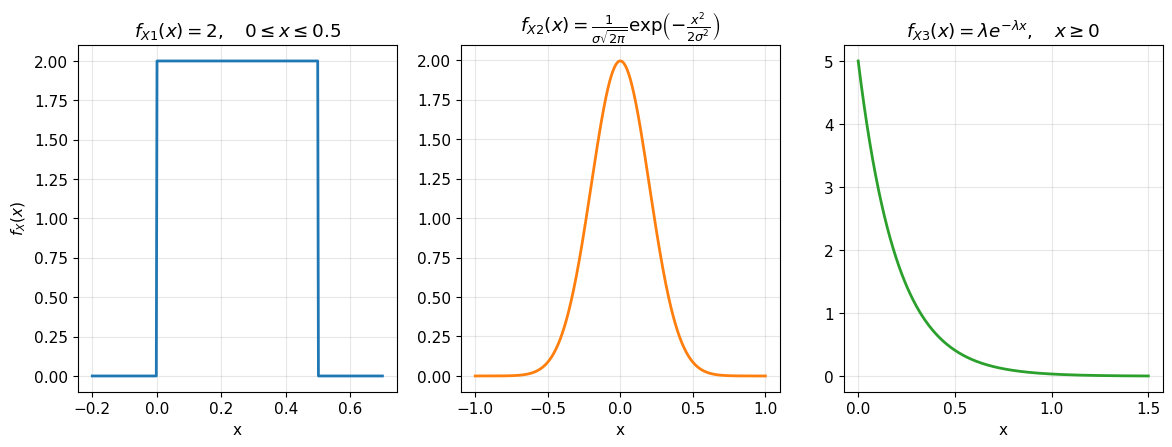

In [43]:
# Crea una figura de 1 renglón y 3 columnas,
# Es una sóla figura con 3 subplots
# La figura tien un ancho de 14 y un alto de 4.5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

indice_figura = 0
X1 = stats.uniform(loc=0, scale=0.5) # intervalo en que toma valor continuo diferente de 0
eje_x = np.linspace(-0.2, 0.7, 400)
f_x1 = X1.pdf(eje_x)
titulo = r'$f_{X1}(x)=2, \quad 0 \leq x \leq 0.5$'
grafica(axes, indice = indice_figura, f_x=f_x1, eje_x=eje_x, titulo=titulo)

indice_figura = 1
sigma = 0.2
X2 = stats.norm(loc=0, scale=sigma) # La función esta centrado loc=0
eje_x = np.linspace(-1, 1, 400)
f_x2 = X2.pdf(eje_x)
titulo = r'$f_{X2}(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{x^2}{2\sigma^2}\right)$'
grafica(axes, indice = indice_figura, f_x=f_x2, eje_x=eje_x, titulo=titulo)

indice_figura = 2
lam = 5
X3 = stats.expon(scale=1/lam) #valor de lambda
eje_x = np.linspace(0, 1.5, 400)
f_x3 = X3.pdf(eje_x)
titulo = r'$f_{X3}(x) = \lambda e^{-\lambda x}, \quad x \geq 0$'
grafica(axes, indice = indice_figura, f_x=f_x3, eje_x=eje_x, titulo=titulo)

### 3.2 Verificación numérica: a pesar de que $f_X(x) > 1$, el área total bajo la curva es 1 y las probabilidades de intervalos siempre son $≤ 1$

In [44]:
print(f"{'Distribución':<25} {'máx f(x)':>10} {'∫ f(x) dx':>12} {'P(0≤X≤0.1)':>14}")
print("-" * 65)
for nombre, dist, lo, hi, maxf in [
    (r'f_X1', X1, -1,  1,   2.0),
    (r'f_X2', X2, -5,  5,   2.0),
    (r'f_X3', X3,  0,  100, 5.0),
]:
    area, _ = integrate.quad(dist.pdf, lo, hi) 
    p_int = dist.cdf(0.1) - dist.cdf(0)
    print(f'{nombre:<25} {maxf:>10.3f} {area:>12.6f} {p_int:>14.6f}')

Distribución                máx f(x)    ∫ f(x) dx     P(0≤X≤0.1)
-----------------------------------------------------------------
f_X1                           2.000     1.000000       0.200000
f_X2                           2.000     1.000000       0.191462
f_X3                           5.000     1.000000       0.393469


## 4. Ejemplo

La vida útil (en horas) de una laptop está dada por una variable aleatoria continua con PDF

$$f_X(x) = \begin{cases} \lambda e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}, \qquad F_X(x) = \begin{cases} 1 - e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}$$

donde $\lambda = \frac{1}{100}$.

### 4.1 Visualización de PDF y CDF

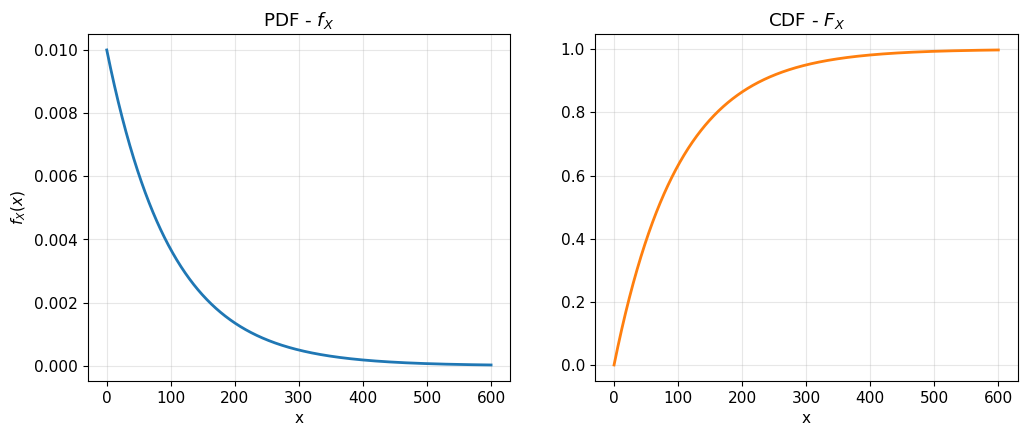

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Datos de la Variable aleatoria
lam =.01
X = stats.expon(scale=1/lam)
eje_x = np.linspace(0, 600, 1000)

# PDF
pdf_vals = X.pdf(eje_x)
indice_figura = 0
titulo = 'PDF - $f_X$'
grafica(axes, indice = indice_figura, f_x=pdf_vals, eje_x=eje_x, titulo=titulo)

# CDF
cdf_vals = X.cdf(eje_x)
indice_figura = 1
titulo = 'CDF - $F_X$'
grafica(axes, indice = indice_figura, f_x=cdf_vals, eje_x=eje_x, titulo=titulo)


### 4.1 Visualización de la probabilidad acumulada
Probabilidad de que una laptop tenga una vida útil menor a 100 hrs.

In [48]:
def grafica_pdf_cdf_x0(x0, eje_x, X):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Panel izquierdo: PDF con área sombreada hasta x0 ---
    # Dibuja la función
    axes[0].plot(eje_x, X.pdf(eje_x), color='C0', lw=2, label=r'$f_X(x)$')
    # Sombrea el intervalo
    mask = eje_x <= x0
    axes[0].fill_between(eje_x[mask], X.pdf(eje_x)[mask], alpha=0.4, color='C0',
             label=fr'Área = $F_X({x0}) = {X.cdf(x0):.4f}$')
    # linea vertical en el punto de evaluación
    axes[0].axvline(x0, color='k', ls='--', lw=1)
    
    axes[0].set_title('PDF: el área sombreada es la probabilidad acumulada')
    axes[0].set_xlabel('x') 
    axes[0].set_ylabel(r'$f_X(x)$')
    axes[0].legend()

    # --- Panel derecho: CDF marcando el valor en x0 ---
    # Dibuja la función
    axes[1].plot(eje_x, X.cdf(eje_x), color='C3', lw=2, label=r'$F_X(x)$')
    # lineas verticales y horizaontales para el punto de evaluacion
    axes[1].axvline(x0, color='k', ls='--', lw=1)
    axes[1].axhline(X.cdf(x0), color='k', ls=':', lw=1)
    # Dibuja el punto de evaluacion
    axes[1].plot(x0, X.cdf(x0), 'o', color='C3', ms=8)
    # Coloca una nota del punto de evaluacion
    axes[1].annotate(fr'$F_X({x0}) = {X.cdf(x0):.4f}$',
         xy=(x0, X.cdf(x0)), xytext=(x0+0.4, X.cdf(x0)-0.15),
         arrowprops=dict(arrowstyle='->'))
    
    axes[1].set_title('CDF: la altura en $x_0$ es ese mismo valor')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel(r'$F_X(x)$')
    axes[1].set_ylim(-0.02, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

**Parámetros de la funcion grafica_pdf_cdf_x0**
- x0: Punto de evaluación 
- eje_x: Valores del eje x.
- X: Tipo de variable aleatoria. En este caso: Uniforme, Normal y Exponencial.

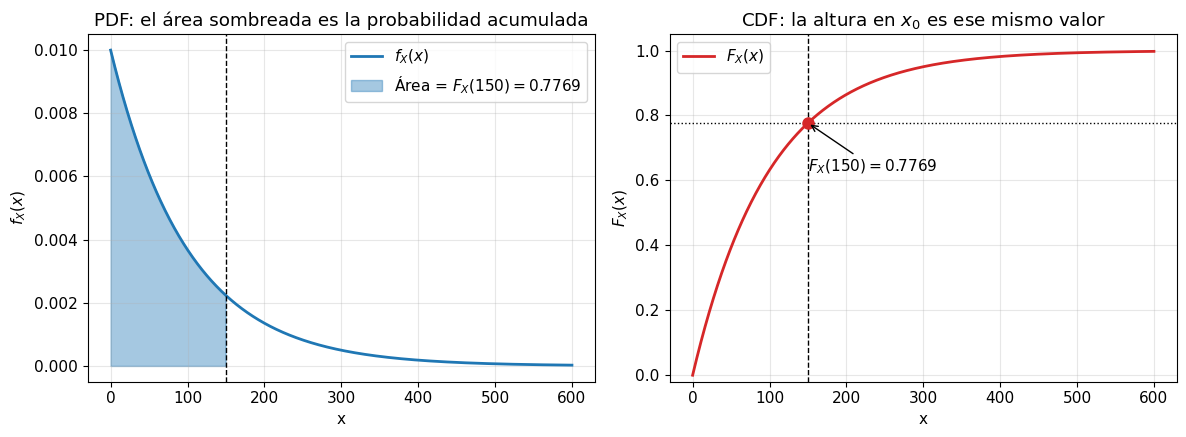

In [49]:
x0 = 150  # punto de evaluación
# Datos de la Variable aleatoria
lam =.01
X = stats.expon(scale=1/lam)
eje_x = np.linspace(0, 600, 1000)

grafica_pdf_cdf_x0(x0, eje_x, X)

Derivar la CDF recupera la PDF.

### 4.3 Cálculo de la probabilidad en un intervalo
Probabilidad de que una laptop tenga una vida útil entre 50 y 100 hrs. - $\mathbb{P}(50 \leq X \leq 100)$

In [52]:
# Datos de la Variable aleatoria
lam =.01
X = stats.expon(scale=1/lam)
eje_x = np.linspace(0, 600, 1000)

# Intervalos par calculo de probabilidad
a = 50
b = 100

# Cálculo integrando la PDF
p_int, _ = integrate.quad(X.pdf, a, b) 
print(f"∫ f(x) dx = {p_int}")


# Cálculo con la diferencia de la CDF en los intervalos

p_int = X.cdf(b) - X.cdf(a)

print("P(50<X<100) = F(a)- F(b) = " + str(p_int))

∫ f(x) dx = 0.2386512185411911
P(50<X<100) = F(a)- F(b) = 0.2386512185411911


### 4.2 Visualización de la probabilidad en un intervalo

In [53]:
def grafica_probabilidad_intervalo(a, b, eje_x, X, p_int):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # PDF con la franja [a,b] sombreada
    axes[0].plot(eje_x, X.pdf(eje_x), color='C0', lw=2)
    mask = (eje_x >= a) & (eje_x <= b)
    axes[0].fill_between(eje_x[mask], X.pdf(eje_x)[mask], alpha=0.4, color='C2',
                         label=fr'$P({a}\leq X \leq {b}) \approx {p_int:.4f}$')
    axes[0].set_title('PDF con la probabilidad como área')
    axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$f_X(x)$')
    axes[0].legend()

    # CDF mostrando la diferencia F(b) - F(a)
    axes[1].plot(eje_x, X.cdf(eje_x), color='C3', lw=2)
    for v, color in [(a, 'gray'), (b, 'gray')]:
        axes[1].axvline(v, color=color, ls='--', lw=1)
        axes[1].axhline(X.cdf(v), color=color, ls=':', lw=1)
    axes[1].annotate('', xy=(0.05, X.cdf(b)), xytext=(0.05, X.cdf(a)),
                     arrowprops=dict(arrowstyle='<->', color='C2', lw=2))
    axes[1].text(0.15, (X.cdf(a)+X.cdf(b))/2, fr'$F({b})-F({a})$', color='C2')
    axes[1].set_title('CDF: la misma probabilidad como diferencia vertical')
    axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$F_X(x)$')
    axes[1].set_ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()

**Parámetros de la funcion grafica_pdf_cdf_x0**
- a, b: Intervalo de evaluación 
- eje_x: Valores del eje x.
- X: Tipo de variable aleatoria. En este caso: Uniforme, Normal y Exponencial.
- p_int: Probabilidad en el intervalo (a,b)

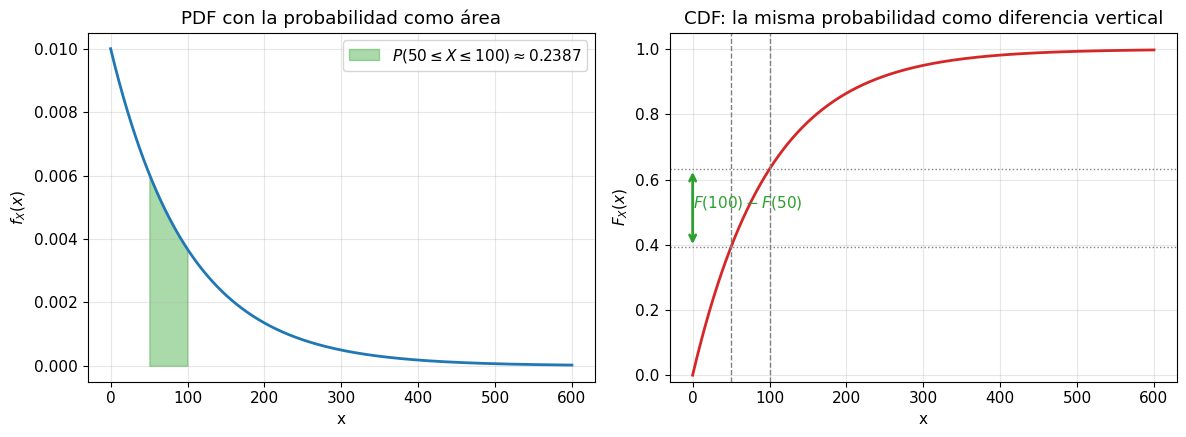

In [54]:
grafica_probabilidad_intervalo(a, b, eje_x, X, p_int)

## 5. Ejercicios 

En la celda 11, se definen 3 PFD: uniforme, normal y exponencial.

### Ejercicio 1 — Distribución uniforme

1. Crea una PDF uniforme con parámetros $X \sim \mathcal{U}(2, 7)$.
2. Usa la función grafica_pdf_cdf_x0 para visualizar P(X<4).
3. Usa la función integrate.quad para calcular P(3<X<5).
4. Usa la función X.cdf para calcular P(3<X<5)
5. Usa la función grafica_probabilidad_intervalo para visulizar P(3<X<5).

### Ejercicio 2 — Distribución normal

1. Crea una PDF uniforme con parámetro $\sigma = 0.4)$.
2. Usa la función grafica_pdf_cdf_x0 para visualizar P(X<0.5).
3. Usa la función integrate.quad para calcular P(-0.3<X<0.5).
4. Usa la función X.cdf para calcular P(-0.3<X<0.5)
5. Usa la función grafica_probabilidad_intervalo para visulizar P(-0.3<X<0.5).

### Ejercicio 3 — Distribución exponencial

1. Crea una PDF uniforme con parámetro $\lambda = 4)$.
2. Usa la función grafica_pdf_cdf_x0 para visualizar P(X<0.3).
3. Usa la función integrate.quad para calcular P(0<X<0.3).
4. Usa la función X.cdf para calcular P(0<X<0.3)
5. Usa la función grafica_probabilidad_intervalo para visulizar P(0<X<0.3).

## Ejercicio 1